# 07 — Sentinel-1 SAR

Sentinel-1 Ground Range Detected (GRD) radar backscatter (`vv`, `vh`) extracted on the Major TOM grid, using the **same** built-ins as the optical examples: `search_stac` + `read_odc_stac` + `reproject_odc` + `write_geotiff`. No new plugin needed — SAR is just another STAC collection.

Data comes from Microsoft Planetary Computer's `sentinel-1-grd` collection (Cloud-Optimized GeoTIFFs), so no credentials are required.

In [1]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[viz,pc]"

In [2]:
# Download config files and AOIs from the GitHub repository so this
# notebook can run outside the repo (e.g. Google Colab).
import os
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/frandorr/aereo/main"

os.makedirs("config/aoi", exist_ok=True)

# Config files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_sentinel1.yaml",
    "config/job_sentinel1.yaml",
)

# AOI files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/aoi/chocon.geojson",
    "config/aoi/chocon.geojson",
)

## Config used in this notebook

`config/job_sentinel1.yaml` queries Planetary Computer for `sentinel-1-grd` (`vv`/`vh`) over the Chocón reservoir AOI. Two SAR-specific details live in the `read` section:

- `crs: "EPSG:32719"` and `resolution: 10` — PC's Sentinel-1 items carry no `proj` metadata, so `odc-stac` cannot auto-guess the native grid (UTM 19S, 10 m) and we declare it explicitly.
- `patch_url: planetary_computer.sign` — signs asset URLs at load time, same as the Sentinel-2 PC quickstart.

In [3]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

# Load the job from the Hydra config package.
job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_sentinel1",
)

In [4]:
assets = job.search()  # Use the search method from the job object to get the assets.
tasks = job.build_tasks(assets)
len(tasks)

2026-07-27 10:56:21 [info     ] search_called                  provider=search_stac


2026-07-27 10:56:23 [info     ] build_tasks_start              assets=4 builder=build_grouped_tasks


/home/fran/repos/aereo/.venv/lib/python3.13/site-packages/pydantic/_internal/_validate_call.py:137: UserWarning: assets has no 'crs' column; assuming all assets share the same native CRS. Mixed-CRS assets in one task may fail or produce incorrect results.
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


2

In [5]:
# now we create an Executor, in this case a LocalExecutor to run
# each ExtractionTask using Threads
local_exec = LocalExecutor(workers=-1, use_threads=True, cache=TaskResultCache())

In [6]:
# Extract!
print("Extracting...")
artifacts = job.execute(tasks, executor=local_exec)
print(f"✓ Extracted {len(artifacts)} artifacts")

Extracting...
2026-07-27 10:56:23 [info     ] execute_start                  executor=LocalExecutor task_count=2


✓ Extracted 20 artifacts


## Plot the extracted patches

`vv` backscatter in linear units, rendered with a grayscale percentile stretch. Dark open water in the reservoir contrasts with brighter land — the classic SAR signature, available day or night and through clouds.

(<Figure size 2000x1495.93 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


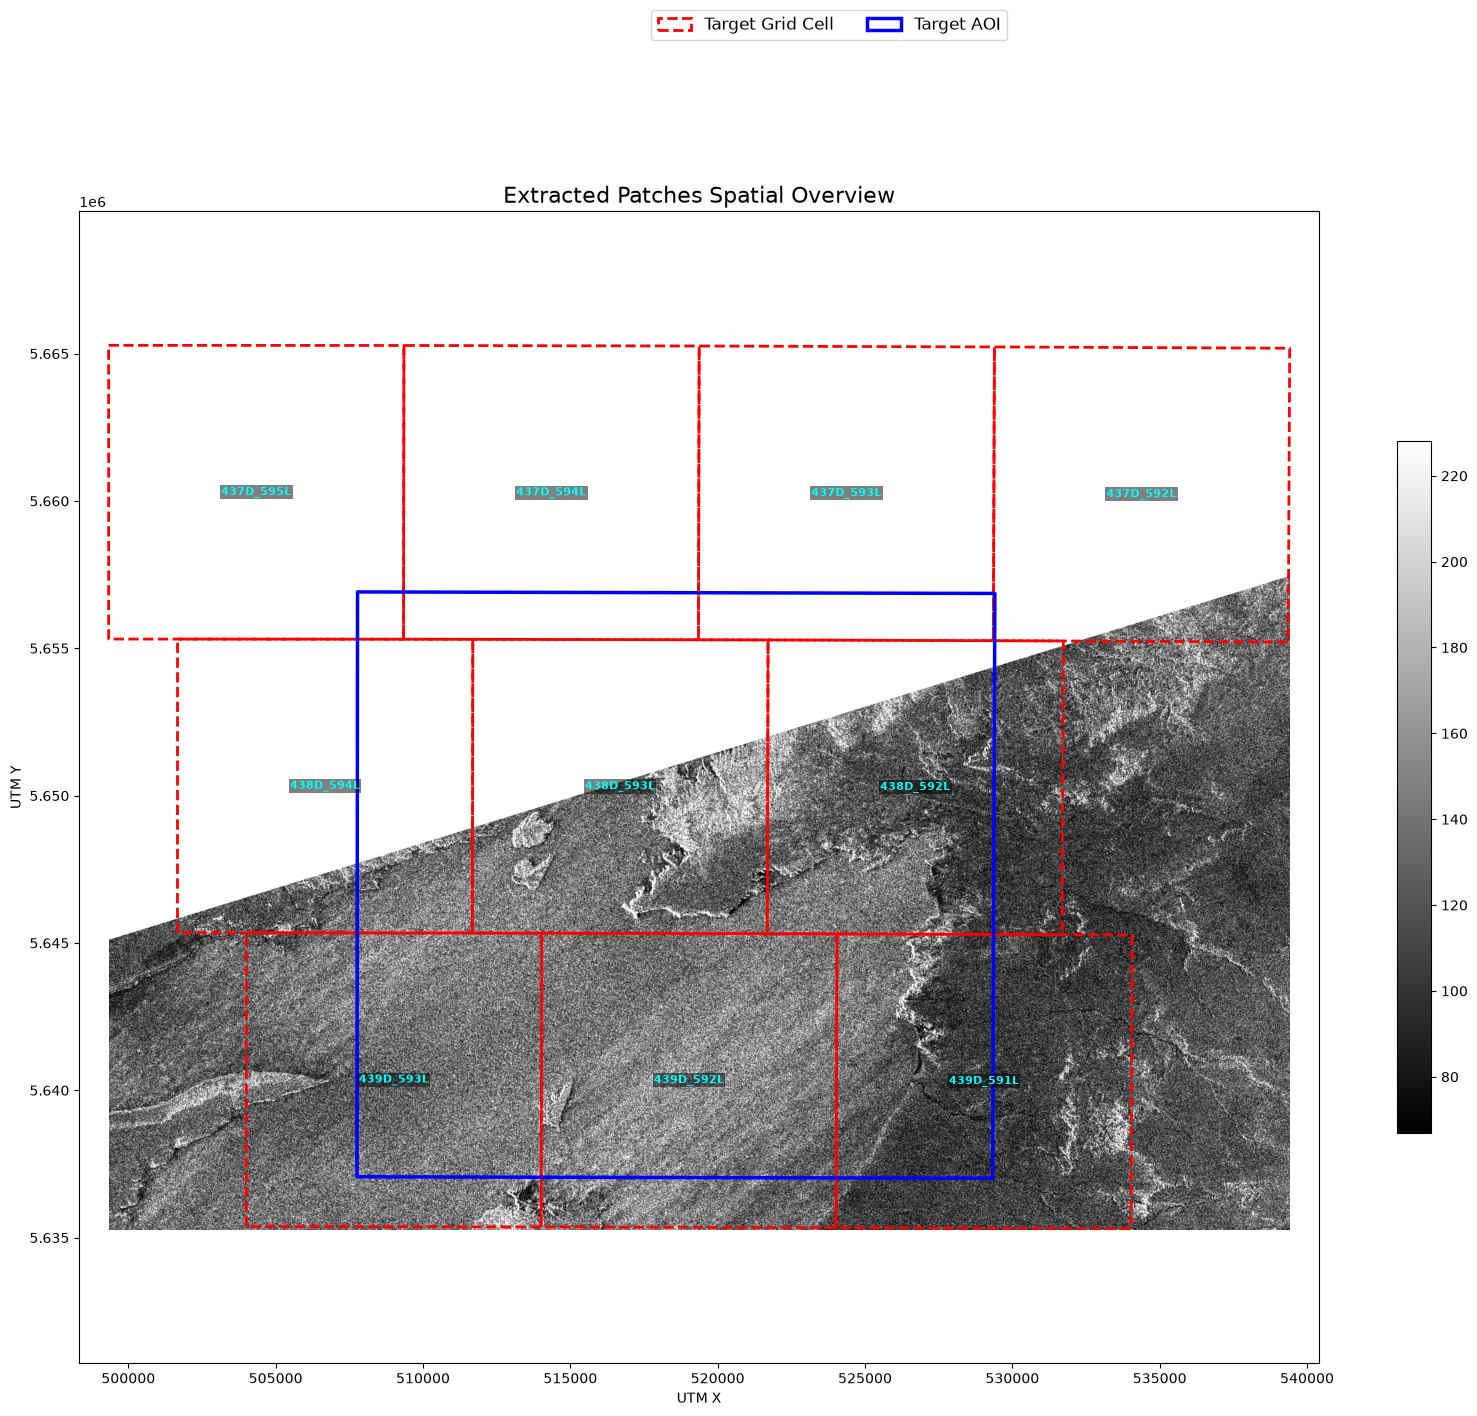

In [7]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(
    artifacts,
    ds_factor=1,
    cmap="gray",
    stretch="percentile",
    aoi=job.target_aoi,
    aoi_edgecolor="blue",
)